## **0. Initialization**

### **Installation**
LoopDetectR is on CRAN and can be installed within R by

In [ ]:
# Before running the R code cells in jupyter notebook,
# initialize the R kernel by this line of code:
# IRkernel::installspec()

In [ ]:
# Download and install
install.packages("LoopDetectR")

Installing package into 'C:/Users/Admin/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)



package 'LoopDetectR' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\Admin\AppData\Local\Temp\Rtmpk1kCL5\downloaded_packages


In [ ]:
install.packages("deSolve")  # if not already installed
install.packages("numDeriv") # if not already installed

Installing package into 'C:/Users/Admin/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)



package 'deSolve' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\Admin\AppData\Local\Temp\Rtmpk1kCL5\downloaded_packages


Installing package into 'C:/Users/Admin/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)



package 'numDeriv' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\Admin\AppData\Local\Temp\Rtmpk1kCL5\downloaded_packages


In [1]:
# Load package
library("LoopDetectR")
library(deSolve)
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.2.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
colors <- c('#EE7733', '#0077BB', '#33BBEE', '#EE3377', '#CC3311', '#009988', '#BBBBBB')

## **1. Model definition**

#### **Example 5: Reduced MAPK Model (with and without explicit feedback)**

The model for the mitogen-activated phosphorylation kinase (MAPK) cascade proposed in [7] captures the first, second and third level of a phosphorylation cascade which occurs for example in epidermal growth factor (EGF) signaling. The kinase on the first level can be reversibly phosphorylated once, the kinases on levels two andthree can be reversibly phosphorylated twice. The phosphorylated kinase of the first level acts positively on the phosphorylations on the second level, the double phosphorylated kinase of the second level acts positively on the phosphorylations on the third level. The model contains an explicit negative feedback regulation: The double phosphorylated kinase of the third level acts negatively on the phosphorylation on the first level. All phosphorylations are governed by Michaelis-Menten kinetics. The model contains eight variables, ten rate coefficients, eleven inhibition or activation constants, and one Hill coefficient.

$$
\begin{aligned}
\frac{dS_1}{dt} &=
- k_1 \, \frac{S_1}{kn_2 + S_1} \, \frac{kn_1^{n_1}}{kn_1^{n_1} + S_8^{n_1}}
+ k_2 \, \frac{S_2}{S_2 + kn_3}, \\[8pt]

\frac{dS_2}{dt} &=
\phantom{-}\, k_1 \, \frac{S_1}{kn_2 + S_1} \, \frac{kn_1^{n_1}}{kn_1^{n_1} + S_8^{n_1}}
- k_2 \, \frac{S_2}{S_2 + kn_3}, \\[10pt]

\frac{dS_3}{dt} &=
\phantom{-}\, k_6 \, \frac{S_4}{kn_7 + S_4}
- k_3 \, \frac{S_2 \, S_3}{kn_4 + S_3}, \\[10pt]

\frac{dS_4}{dt} &=
\phantom{-}\, k_3 \, \frac{S_2 \, S_3}{kn_4 + S_3}
- k_6 \, \frac{S_4}{kn_7 + S_4}
+ k_5 \, \frac{S_5}{kn_6 + S_5}
- k_4 \, \frac{S_2 \, S_4}{kn_5 + S_4}, \\[10pt]

\frac{dS_5}{dt} &=
\phantom{-}\, k_4 \, \frac{S_2 \, S_4}{kn_5 + S_4}
- k_5 \, \frac{S_5}{kn_6 + S_5}, \\[10pt]

\frac{dS_6}{dt} &=
\phantom{-}\, k_{10} \, \frac{S_7}{kn_{11} + S_7}
- k_7 \, \frac{S_5 \, S_6}{kn_8 + S_6}, \\[10pt]

\frac{dS_7}{dt} &=
\phantom{-}\, k_7 \, \frac{S_5 \, S_6}{kn_8 + S_6}
- k_{10} \, \frac{S_7}{kn_{11} + S_7}
- k_8 \, \frac{S_5 \, S_7}{kn_9 + S_7}
+ k_9 \, \frac{S_8}{kn_{10} + S_8}, \\[10pt]

\frac{dS_8}{dt} &=
\phantom{-}\, k_8 \, \frac{S_5 \, S_7}{kn_9 + S_7}
- k_9 \, \frac{S_8}{kn_{10} + S_8}.
\end{aligned}
$$


In the table below, the notation we used is given together with the notation used in the original publication [7], and we provide the initial conditions and reference parameter set published together with the model.

**Initial conditions**

| Var | Name (short) | Name (long) | Initial value |
|------:|-------------|-------------|---------------|
| S₁ | MKKK | MAPKKK | 100 nM |
| S₂ | MKKK-P | MAPKKK* | 0 |
| S₃ | MKK | MAPKK | 300 nM |
| S₄ | MKK-P | MAPKK* | 0 |
| S₅ | MKK-PP | MAPKK** | 0 |
| S₆ | MAPK | MAPK | 300 nM |
| S₇ | MAPK-P | MAPK* | 0 |
| S₈ | MAPK-PP | MAPK** | 0 |


**Parameters**
| Parameter | Symbol | Value | Units |
|----------:|--------|-------|-------|
| k₁ | V₁ | 2.5 | nM·s⁻¹ |
| k₂ | V₂ | 0.25 | nM·s⁻¹ |
| k₃ | k₃ | 0.025 | s⁻¹ |
| k₄ | k₄ | 0.025 | s⁻¹ |
| k₅ | V₅ | 0.75 | nM·s⁻¹ |
| k₆ | V₆ | 0.75 | nM·s⁻¹ |
| k₇ | k₇ | 0.025 | s⁻¹ |
| k₈ | k₈ | 0.025 | s⁻¹ |
| k₉ | V₉ | 0.5 | nM·s⁻¹ |
| k₁₀ | V₁₀ | 0.5 | nM·s⁻¹ |


The MAPK cascade model without explicit feedback regulation is exactly the same as the one described above, but for the corresponding regulation term omitted from the ODE system. Therefore, only the first two equations of the ODE model are altered to:

$$
\begin{aligned}
\frac{dS_1}{dt} &=
- k_1 \, \frac{S_1}{kn_2 + S_1}
+ k_2 \, \frac{S_2}{S_2 + kn_3}, \\[8pt]

\frac{dS_2}{dt} &=
\phantom{-}\, k_1 \, \frac{S_1}{kn_2 + S_1}
- k_2 \, \frac{S_2}{S_2 + kn_3}.
\end{aligned}
$$


#### **1.1. Reduced MAPK Model with aexplicit feedback**

In [117]:
model_mapk_simple_w_feedback <- function(t, y, klin, kn, n1) {
  # Unpack state
  S1 <- y[1]; S2 <- y[2]; S3 <- y[3]; S4 <- y[4]
  S5 <- y[5]; S6 <- y[6]; S7 <- y[7]; S8 <- y[8]

  # Kinetic parameters
  k1 <- klin[1];  k2 <- klin[2];  k3 <- klin[3];  k4 <- klin[4];  k5 <- klin[5]
  k6 <- klin[6];  k7 <- klin[7];  k8 <- klin[8];  k9 <- klin[9];  k10 <- klin[10]

  # Saturation constants
  kn1 <- kn[1];  kn2 <- kn[2];  kn3 <- kn[3];  kn4 <- kn[4];  kn5 <- kn[5]
  kn6 <- kn[6];  kn7 <- kn[7];  kn8 <- kn[8];  kn9 <- kn[9];  kn10 <- kn[10]
  kn11 <- kn[11]

  # dS1/dt
  term_inhibit <- (kn1^n1) / (kn1^n1 + S8^n1)
  dS1 <- -k1 * (S1/(kn2 + S1)) * term_inhibit +
          k2 * (S2/(S2 + kn3))

  # dS2/dt
  dS2 <-  k1 * (S1/(kn2 + S1)) * term_inhibit -
          k2 * (S2/(S2 + kn3))

  # dS3/dt
  dS3 <-  k6 * (S4/(kn7 + S4)) -
          k3 * (S2*S3/(kn4 + S3))

  # dS4/dt
  dS4 <-  k3 * (S2*S3/(kn4 + S3)) -
          k6 * (S4/(kn7 + S4)) +
          k5 * (S5/(kn6 + S5)) -
          k4 * (S2*S4/(kn5 + S4))

  # dS5/dt
  dS5 <-  k4 * (S2*S4/(kn5 + S4)) -
          k5 * (S5/(kn6 + S5))

  # dS6/dt
  dS6 <-  k10 * (S7/(kn11 + S7)) -
          k7  * (S5*S6/(kn8 + S6))

  # dS7/dt
  dS7 <-  k7  * (S5*S6/(kn8 + S6)) -
          k10 * (S7/(kn11 + S7)) -
          k8  * (S5*S7/(kn9 + S7)) +
          k9  * (S8/(kn10 + S8))

  # dS8/dt
  dS8 <-  k8 * (S5*S7/(kn9 + S7)) -
          k9 * (S8/(kn10 + S8))
  
  dx <- rep(0,8)
  dx[1] <- dS1
  dx[2] <- dS2
  dx[3] <- dS3
  dx[4] <- dS4
  dx[5] <- dS5
  dx[6] <- dS6
  dx[7] <- dS7
  dx[8] <- dS8
  
  return(dx)
}

### **1.2. Reduced MAPK Model without explicit feedback**

In [116]:
model_mapk_simple_wo_feedback <- function(t, y, klin, kn, n1) {
  # Unpack state
  S1 <- y[1]; S2 <- y[2]; S3 <- y[3]; S4 <- y[4]
  S5 <- y[5]; S6 <- y[6]; S7 <- y[7]; S8 <- y[8]

  # Kinetic parameters
  k1 <- klin[1];  k2 <- klin[2];  k3 <- klin[3];  k4 <- klin[4];  k5 <- klin[5]
  k6 <- klin[6];  k7 <- klin[7];  k8 <- klin[8];  k9 <- klin[9];  k10 <- klin[10]

  # Saturation constants
  kn1 <- kn[1];  kn2 <- kn[2];  kn3 <- kn[3];  kn4 <- kn[4];  kn5 <- kn[5]
  kn6 <- kn[6];  kn7 <- kn[7];  kn8 <- kn[8];  kn9 <- kn[9];  kn10 <- kn[10]
  kn11 <- kn[11]

  # dS1/dt
  dS1 <- -k1 * (S1/(kn2 + S1)) +
          k2 * (S2/(S2 + kn3))

  # dS2/dt
  dS2 <-  k1 * (S1/(kn2 + S1)) -
          k2 * (S2/(S2 + kn3))

  # dS3/dt
  dS3 <-  k6 * (S4/(kn7 + S4)) -
          k3 * (S2*S3/(kn4 + S3))

  # dS4/dt
  dS4 <-  k3 * (S2*S3/(kn4 + S3)) -
          k6 * (S4/(kn7 + S4)) +
          k5 * (S5/(kn6 + S5)) -
          k4 * (S2*S4/(kn5 + S4))

  # dS5/dt
  dS5 <-  k4 * (S2*S4/(kn5 + S4)) -
          k5 * (S5/(kn6 + S5))

  # dS6/dt
  dS6 <-  k10 * (S7/(kn11 + S7)) -
          k7  * (S5*S6/(kn8 + S6))

  # dS7/dt
  dS7 <-  k7  * (S5*S6/(kn8 + S6)) -
          k10 * (S7/(kn11 + S7)) -
          k8  * (S5*S7/(kn9 + S7)) +
          k9  * (S8/(kn10 + S8))

  # dS8/dt
  dS8 <-  k8 * (S5*S7/(kn9 + S7)) -
          k9 * (S8/(kn10 + S8))
  
  dx <- rep(0,8)
  dx[1] <- dS1
  dx[2] <- dS2
  dx[3] <- dS3
  dx[4] <- dS4
  dx[5] <- dS5
  dx[6] <- dS6
  dx[7] <- dS7
  dx[8] <- dS8
  
  return(dx)
}

## **2. Result reproduction**

In [35]:
# Parameters from supplementary material
klin <- c(
  2.5,   # k1
  0.25,  # k2
  0.025, # k3
  0.025, # k4
  0.75,  # k5
  0.75,  # k6
  0.025, # k7
  0.025, # k8
  0.5,   # k9
  0.5    # k10
)

kn <- c(
  9,   # kn1 = KI
  10,  # kn2 = K1
  8,   # kn3 = K2
  15,  # kn4
  15,  # kn5
  15,  # kn6
  15,  # kn7
  15,  # kn8
  15,  # kn9
  15,  # kn10
  15   # kn11
)

n1 <- 1

# Initial conditions
initial_conditions <- c(
  S1 = 100, # S1: MKKK, MAPKKK
  S2 = 0,   # S2: MKKK-P, MKKK*
  S3 = 300, # S3: MKK, MAPKK
  S4 = 0,   # S4: MKK-P, MAPKK*,
  S5 = 0,   # S5: MKK-PP, MAPKK**
  S6 = 300, # S6: MAPK, MAPK
  S7 = 0,   # S7: MAPK-P, MAPK*
  S8 = 0    # S8: MAPK-PP, MAPK** 
)

all_labels <- c('MAPKKK (S1)', 'MAPKKK* (S2)', 'MAPKK (S3)', 'MAPKK* (S4)', 
                'MAPKK** (S5)', 'MAPK (S6)', 'MAPK* (S7)', 'MAPK** (S8)')


### **2.1. Reduced MAPK Model with explicit feedback**

#### **2.1.1. Loop structure (at first)**

In [32]:
# compute loops
res_tab <- find_loops_vset(model_mapk_simple_w_feedback,vset=list(initial_conditions),t=1,klin=klin,kn=kn,n1=n1,max_num_loops=10)
# The loop list is reported
res_tab$loop_rep[[1]] 
# To access a specific loop representation: e.g., the sixth loop, add [6,]

loop,length,sign
<I<list>>,<dbl>,<dbl>
"1, 1",1,-1
"2, 2",1,-1
"4, 4",1,-1
"5, 5",1,-1
"7, 7",1,-1
"8, 8",1,-1
"1, 2, 1",2,1


In [11]:
loop_summary(res_tab$loop_rep[[1]])

,len_1,len_2
,<dbl>,<dbl>
all,6,1
pos,0,1
neg,6,0


In [12]:
# Index of node of interest
noi <- 2 
# Return all loops from loop_list containing node 2
loop_list <- res_tab$loop_rep[[1]]
loop_list[vapply(loop_list$loop,function(x){noi %in% x},logical(1)),]

,loop,length,sign
,<I<list>>,<dbl>,<dbl>
2,"2, 2",1,-1
7,"1, 2, 1",2,1


#### **2.1.2. Calculating the Jacobian matrix**

Sign jacobian matrix can be access via `res_tab` variable that we have calculated above, or derived from a jacobian matrix at a specific state

In [14]:
# The corresponding signed Jacobian matrix (at initialization point)
res_tab$jac_rep[[1]]

-1,1,0,0,0,0,0,1
1,-1,0,0,0,0,0,-1
0,-1,0,1,0,0,0,0
0,1,0,-1,1,0,0,0
0,0,0,0,-1,0,0,0
0,0,0,0,-1,0,1,0
0,0,0,0,1,0,-1,1
0,0,0,0,0,0,0,-1


The function jacobian from the numDeriv package can be used to determine numerically the Jacobian matrix of an ODE system at a certain set of values for the variables, `s_star`. The approach is that of finite differences (with real step) or complex step approach, the latter of which is supposed to deliver more exact results [Martins et al., 2003].

In [37]:
# The function func_POSm4 returns a vector, but deSolve needs the vector within
# a list as output. Therefore, we define a function that simply puts the output 
# of func_POSm4 into a list:
func_list <- function(t,x,klin,kn,n1){list(model_mapk_simple_w_feedback(t,x,klin,kn,n1))}
sol <-  deSolve::ode(y = initial_conditions, times = seq(0,3650,1), func = func_list, 
                     parms=klin, kn=kn, n1=n1)

# Set the last point of the numeric solution as point of interest, omit the 
# first column (it contains the time)
s_star_end <- sol[dim(sol)[1],2:dim(sol)[2]]
s_star_end

S1         S2         S3         S4         S5         S6         S7 
 95.651702   4.348298 208.414607  74.515147  17.070247   6.843314  15.191758 
        S8 
277.964928

In [38]:
j_matrix <- numDeriv::jacobian(model_mapk_simple_w_feedback, s_star_end,method="complex",
                               t=3650,klin=klin, kn=kn, n1=n1)
j_matrix

-7.024262e-05,0.013116435,0.000000e+00,0.0000000000,0.000000000,0.00000000,0.000000000,2.473666e-04
7.024262e-05,-0.013116435,0.000000e+00,0.0000000000,0.000000000,0.00000000,0.000000000,-2.473666e-04
0.000000e+00,-0.023321506,-3.266837e-05,0.0014039753,0.000000000,0.00000000,0.000000000,0.000000e+00
0.000000e+00,0.002510742,3.266837e-05,-0.0016074721,0.010938252,0.00000000,0.000000000,0.000000e+00
0.000000e+00,0.020810765,0.000000e+00,0.0002034968,-0.010938252,0.00000000,0.000000000,0.000000e+00
0.000000e+00,0.000000000,0.000000e+00,0.0000000000,-0.007832276,-0.01341634,0.008227814,0.000000e+00
0.000000e+00,0.000000000,0.000000e+00,0.0000000000,-0.004747116,0.01341634,-0.015250355,8.738361e-05
0.000000e+00,0.000000000,0.000000e+00,0.0000000000,0.012579392,0.00000000,0.007022541,-8.738361e-05


In [39]:
signed_jacobian <- sign(j_matrix)
signed_jacobian

-1,1,0,0,0,0,0,1
1,-1,0,0,0,0,0,-1
0,-1,-1,1,0,0,0,0
0,1,1,-1,1,0,0,0
0,1,0,1,-1,0,0,0
0,0,0,0,-1,-1,1,0
0,0,0,0,-1,1,-1,1
0,0,0,0,1,0,1,-1


#### **2.1.3. Temporal dynamics**

In [40]:
sol <- deSolve::ode(y = s_star_end, times = seq(0,5000,1), func = func_list, 
                     parms=klin, kn=kn, n1=n1)

In [44]:
max(sol[,9])

[1] 296.6201

In [43]:
dim(sol)

[1] 5001    9

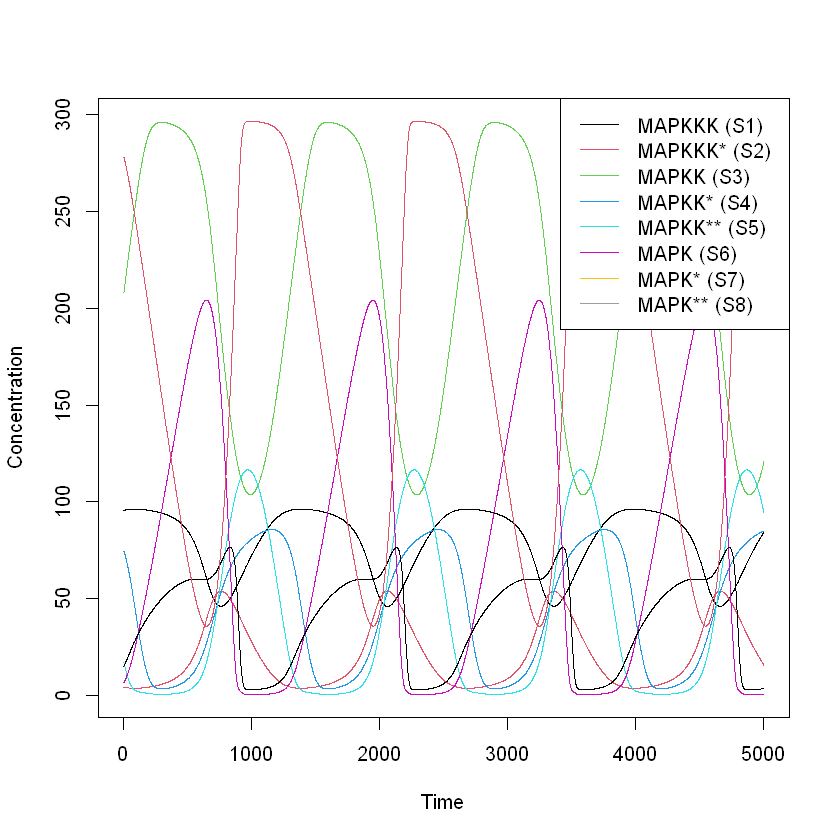

In [54]:
matplot(
  sol[,1], sol[,2:dim(sol)[2]],
  type = "l",
  lty = 1,
  xlab = "Time",
  ylab = "Concentration",
)

legend(
  "topright",
  legend = all_labels,
  col = 1:8,
  lty = 1
)

In [75]:
investigate_label <- c('MAPKK** (S5)', 'MAPK (S6)', 'MAPK* (S7)')
investigate_index <- c(6, 7, 8)

In [76]:
sol_for_plot <- as.data.frame(sol[, c(1, investigate_index)])

# rename columns for clarity (use time + investigate_label)
colnames(sol_for_plot) <- c("time", investigate_label)

# reshape to long format
sol_long <- sol_for_plot %>%
  pivot_longer(cols = `MAPKK** (S5)`:`MAPK* (S7)`, names_to = "species", values_to = "value")

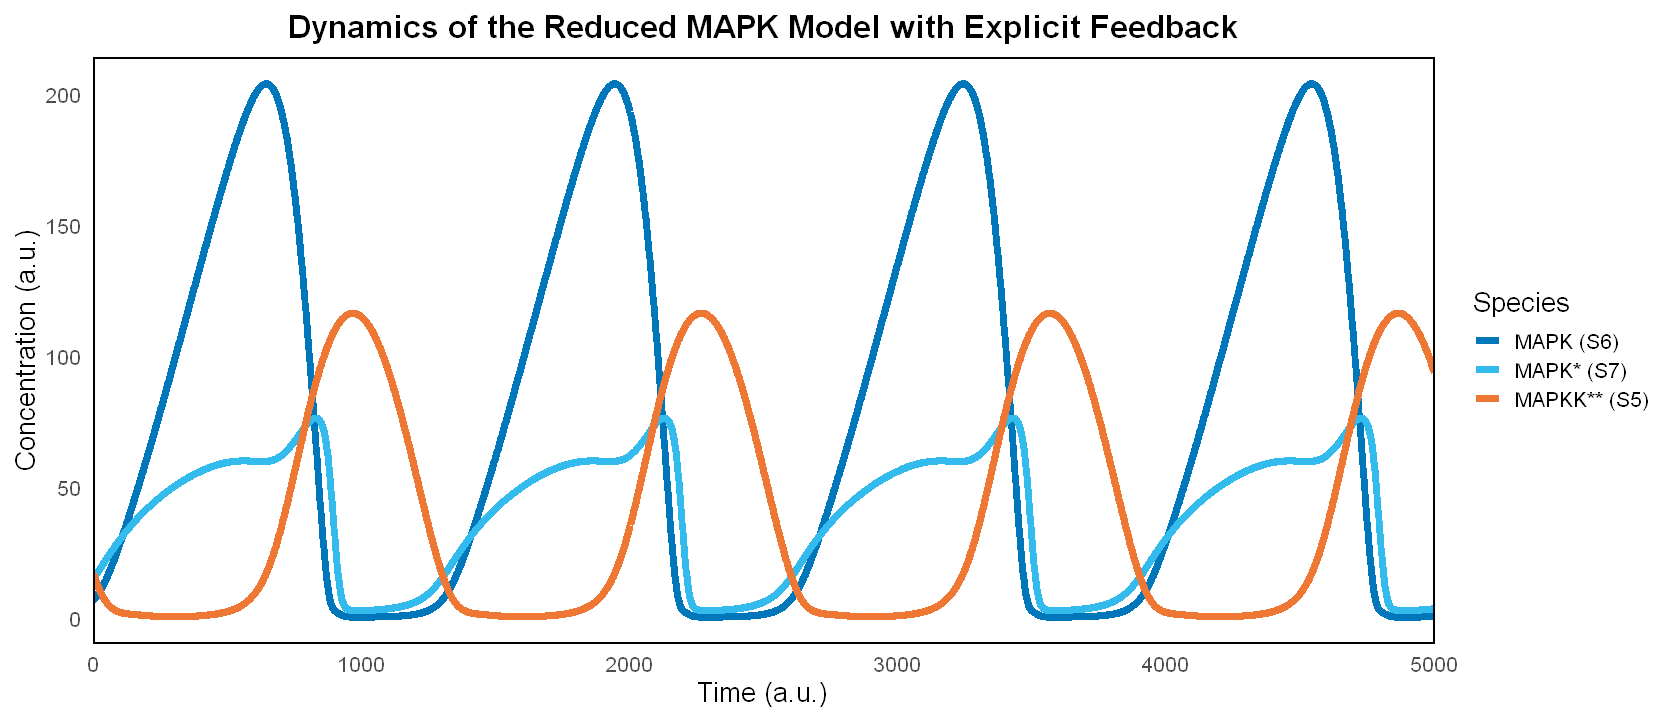

In [107]:
options(repr.plot.width = 14, repr.plot.height = 6)
colors <- c(
  `MAPKK** (S5)` = "#EE7733",
  `MAPK (S6)` = "#0077BB",
  `MAPK* (S7)` = "#33BBEE"
)

plot1 <- ggplot(sol_long, aes(x = time, y = value, colour = species)) +
  geom_line(linewidth = 2) +
  scale_colour_manual(values = colors) + # scale_colour_brewer(palette = "Dark2") +
  scale_x_continuous(
    breaks = seq(0, 5000, 1000),
    minor_breaks = seq(0, 5000, 500),
    limits = c(0, 5000),
    expand = c(0, 0)
  ) +
  coord_cartesian(xlim = c(0, 5000), clip = "on") +
  labs(
    title = "Dynamics of the Reduced MAPK Model with Explicit Feedback",
    x = "Time (a.u.)",
    y = "Concentration (a.u.)",
    colour = "Species"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    plot.title = element_text(face = "bold", hjust = 0.5),
    # panel.grid.minor = element_blank(),
    panel.grid = element_blank(),

    ## black outer box
    panel.border = element_rect(
      colour = "black",
      fill = NA,
      linewidth = 1.1
    )
  )

plot1
# ggsave("POSm4_plot.png", plot1, width = 10, height = 8, units = "in", dpi = 300)

In [101]:
sol_list <- lapply(1:nrow(sol), function(i) as.numeric(sol[i, 2:9]))
res_tab_all <- find_loops_vset(model_mapk_simple_w_feedback,vset=sol_list,t=1,klin=klin,kn=kn,n1=n1)

In [111]:
# Draw background in the plot corresponding to the time points where
# certain loop structures are present

# 1-to-1 time vector (must match loop_rep_index length)
time_vec <- sort(unique(sol_long$time))

stopifnot(length(res_tab_all$loop_rep_index) == length(time_vec))

# Run-length encode to get contiguous segments of the same loop structure
r <- rle(res_tab_all$loop_rep_index)

end_idx   <- cumsum(r$lengths)
start_idx <- c(1, head(end_idx + 1, -1))

bands <- tibble(
  loop_type = factor(r$values),
  t_start   = time_vec[start_idx],
  t_end     = time_vec[end_idx]
)
transition_times <- bands$t_end[-nrow(bands)]

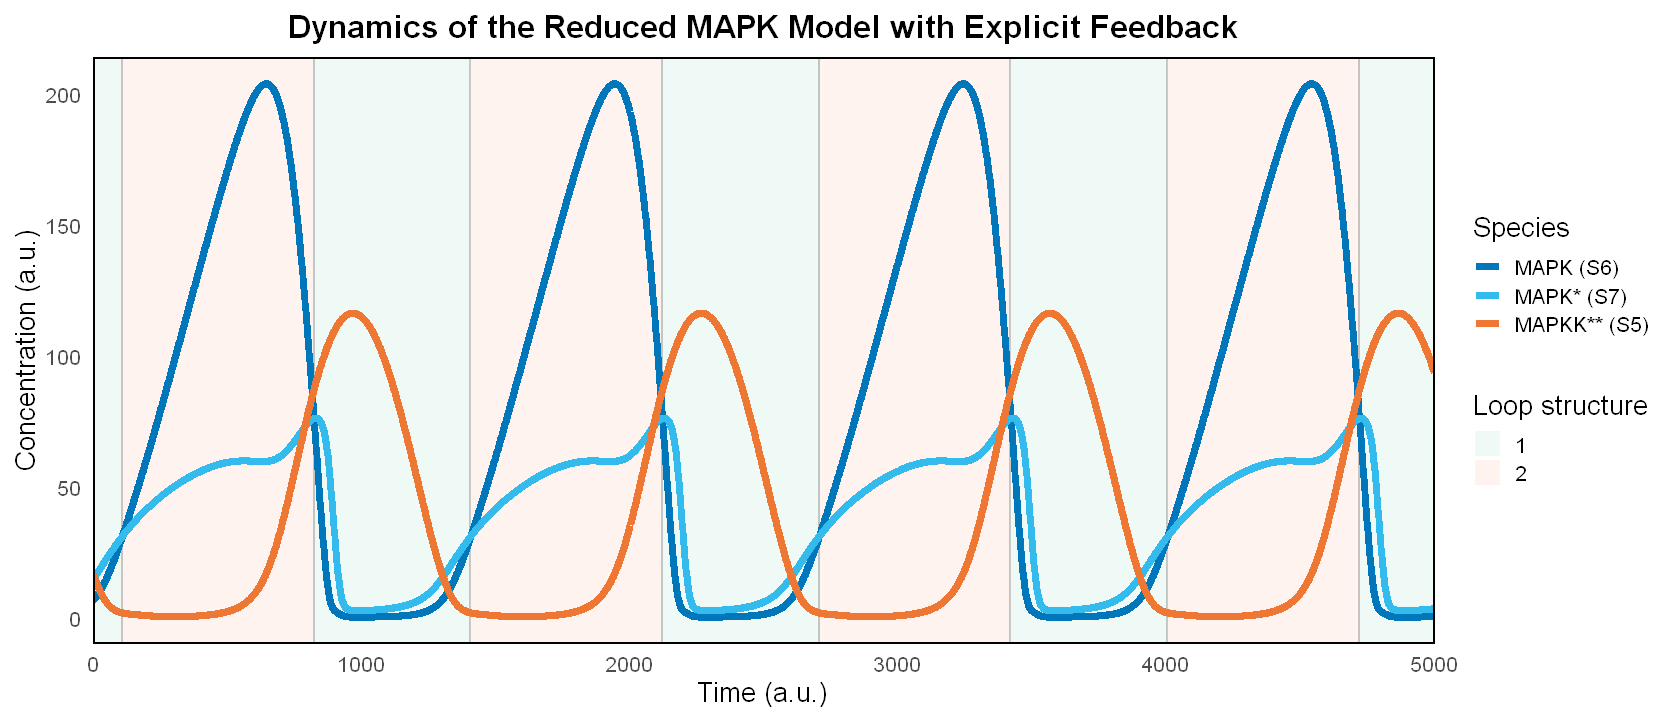

In [112]:
plot2 <- ggplot(sol_long, aes(x = time, y = value, colour = species)) +
  # background bands (behind lines)
  geom_rect(
    data = bands,
    aes(xmin = t_start, xmax = t_end, ymin = -Inf, ymax = Inf, fill = loop_type),
    inherit.aes = FALSE,
    alpha = 0.1
  ) +
  geom_vline(
    xintercept = transition_times,
    colour = "grey40",
    linewidth = 0.7,
    alpha = 0.35
  ) +
  geom_line(linewidth = 2) +
  scale_colour_manual(values = colors) +
  scale_fill_brewer(palette = "Set2", name = "Loop structure") +
  scale_x_continuous(
    breaks = seq(0, 5000, 1000),
    minor_breaks = seq(0, 5000, 500),
    limits = c(0, 5000),
    expand = c(0, 0)
  ) +
  coord_cartesian(xlim = c(0, 5000), clip = "on") +
  labs(
    title = "Dynamics of the Reduced MAPK Model with Explicit Feedback",
    x = "Time (a.u.)",
    y = "Concentration (a.u.)",
    colour = "Species"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    plot.title = element_text(face = "bold", hjust = 0.5),
    panel.grid = element_blank(),
    panel.border = element_rect(colour = "black", fill = NA, linewidth = 1.1)
  )

plot2


In [113]:
loop_summary(res_tab_all$loop_rep[[1]])

,len_1,len_2,len_3,len_4,len_5,len_6,len_7,len_8
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
all,8,5,1,3,5,5,3,1
pos,0,5,0,2,4,1,1,1
neg,8,0,1,1,1,4,2,0


In [114]:
loop_summary(res_tab_all$loop_rep[[2]])

,len_1,len_2,len_3,len_4,len_5,len_6,len_7,len_8
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
all,8,5,1,3,5,5,3,1
pos,0,5,0,1,4,3,0,1
neg,8,0,1,2,1,2,3,0


### **2.2. Reduced MAPK Model without explicit feedback**

#### **2.1.1. Loop structure (at first)**

In [118]:
# compute loops
res_tab <- find_loops_vset(model_mapk_simple_wo_feedback,vset=list(initial_conditions),t=1,klin=klin,kn=kn,n1=n1,max_num_loops=10)
# The loop list is reported
res_tab$loop_rep[[1]] 
# To access a specific loop representation: e.g., the sixth loop, add [6,]

loop,length,sign
<I<list>>,<dbl>,<dbl>
"1, 1",1,-1
"2, 2",1,-1
"4, 4",1,-1
"5, 5",1,-1
"7, 7",1,-1
"8, 8",1,-1
"1, 2, 1",2,1


In [119]:
loop_summary(res_tab$loop_rep[[1]])

,len_1,len_2
,<dbl>,<dbl>
all,6,1
pos,0,1
neg,6,0


In [120]:
# Index of node of interest
noi <- 2 
# Return all loops from loop_list containing node 2
loop_list <- res_tab$loop_rep[[1]]
loop_list[vapply(loop_list$loop,function(x){noi %in% x},logical(1)),]

,loop,length,sign
,<I<list>>,<dbl>,<dbl>
2,"2, 2",1,-1
7,"1, 2, 1",2,1


#### **2.1.2. Calculating the Jacobian matrix**

Sign jacobian matrix can be access via `res_tab` variable that we have calculated above, or derived from a jacobian matrix at a specific state

In [121]:
# The corresponding signed Jacobian matrix (at initialization point)
res_tab$jac_rep[[1]]

-1,1,0,0,0,0,0,0
1,-1,0,0,0,0,0,0
0,-1,0,1,0,0,0,0
0,1,0,-1,1,0,0,0
0,0,0,0,-1,0,0,0
0,0,0,0,-1,0,1,0
0,0,0,0,1,0,-1,1
0,0,0,0,0,0,0,-1


The function jacobian from the numDeriv package can be used to determine numerically the Jacobian matrix of an ODE system at a certain set of values for the variables, `s_star`. The approach is that of finite differences (with real step) or complex step approach, the latter of which is supposed to deliver more exact results [Martins et al., 2003].

In [123]:
# The function func_POSm4 returns a vector, but deSolve needs the vector within
# a list as output. Therefore, we define a function that simply puts the output 
# of func_POSm4 into a list:
func_list <- function(t,x,klin,kn,n1){list(model_mapk_simple_wo_feedback(t,x,klin,kn,n1))}
sol <-  deSolve::ode(y = initial_conditions, times = seq(0,500,1), func = func_list, 
                     parms=klin, kn=kn, n1=n1)

# Set the last point of the numeric solution as point of interest, omit the 
# first column (it contains the time)
s_star_end <- sol[dim(sol)[1],2:dim(sol)[2]]
s_star_end

S1           S2           S3           S4           S5           S6 
  1.01955086  98.98044914   1.43623789   6.07643921 292.48732290   0.06708244 
          S7           S8 
  1.04469161 298.88822595

In [124]:
j_matrix <- numDeriv::jacobian(model_mapk_simple_w_feedback, s_star_end,method="complex",
                               t=3650,klin=klin, kn=kn, n1=n1)
j_matrix

-0.006018131,0.0001747516,0.0000000,0.00000000,0.0000000000,0.0000000,0.00000000,2.196046e-05
0.006018131,-0.0001747516,0.0000000,0.00000000,0.0000000000,0.0000000,0.00000000,-2.196046e-05
0.000000000,-0.0021845600,-0.1373966,0.02532550,0.0000000000,0.0000000,0.00000000,0.000000e+00
0.000000000,-0.0050230608,0.1373966,-0.10888315,0.0001189866,0.0000000,0.00000000,0.000000e+00
0.000000000,0.0072076207,0.0000000,0.08355765,-0.0001189866,0.0000000,0.00000000,0.000000e+00
0.000000000,0.0000000000,0.0000000,0.00000000,-0.0001113063,-0.4831478,0.02913389,0.000000e+00
0.000000000,0.0000000000,0.0000000,0.00000000,-0.0015164776,0.4831478,-0.45519861,7.612218e-05
0.000000000,0.0000000000,0.0000000,0.00000000,0.0016277839,0.0000000,0.42606471,-7.612218e-05


In [125]:
signed_jacobian <- sign(j_matrix)
signed_jacobian

-1,1,0,0,0,0,0,1
1,-1,0,0,0,0,0,-1
0,-1,-1,1,0,0,0,0
0,-1,1,-1,1,0,0,0
0,1,0,1,-1,0,0,0
0,0,0,0,-1,-1,1,0
0,0,0,0,-1,1,-1,1
0,0,0,0,1,0,1,-1


#### **2.1.3. Temporal dynamics**

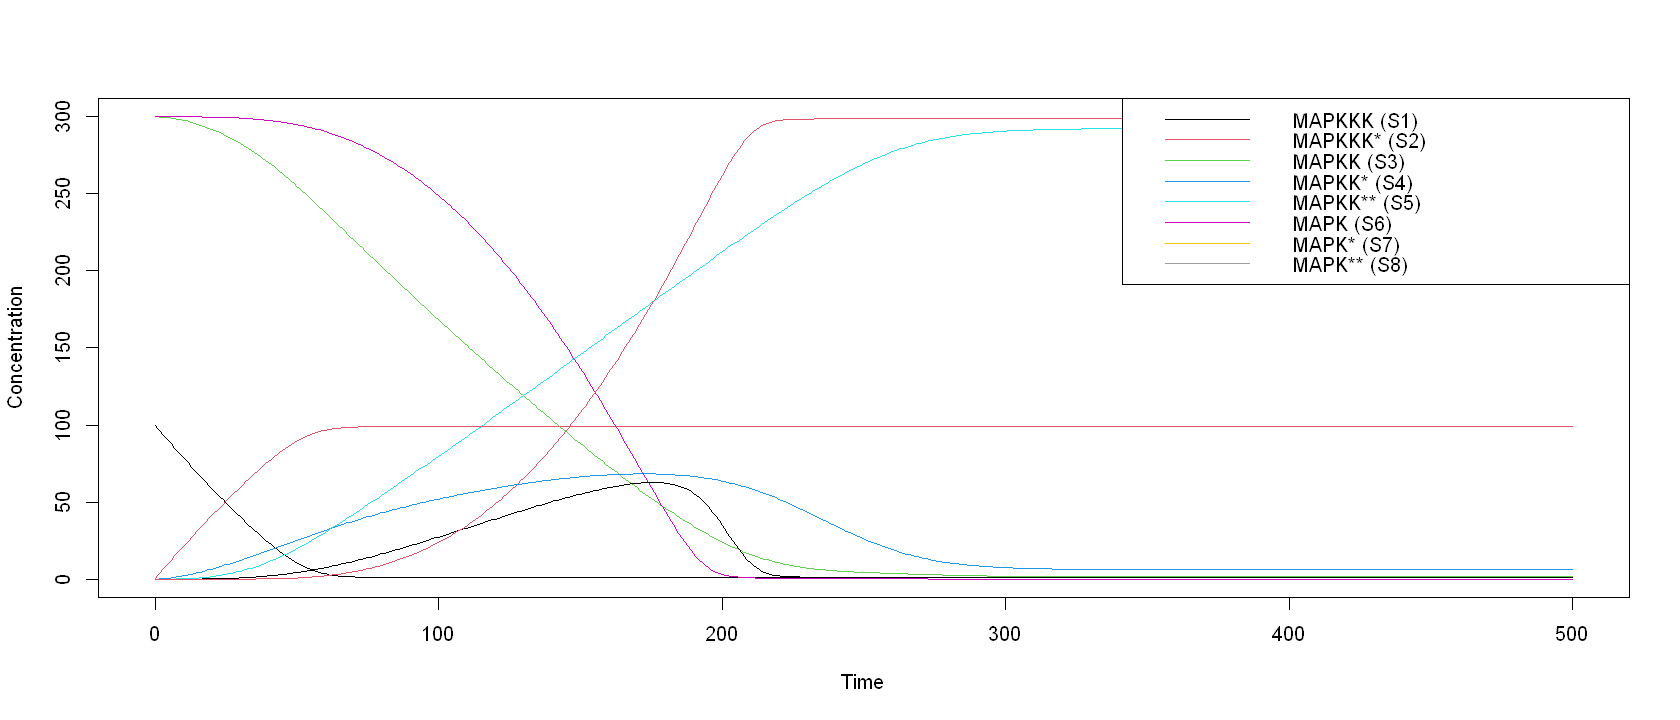

In [126]:
matplot(
  sol[,1], sol[,2:dim(sol)[2]],
  type = "l",
  lty = 1,
  xlab = "Time",
  ylab = "Concentration",
)

legend(
  "topright",
  legend = all_labels,
  col = 1:8,
  lty = 1
)

In [127]:
investigate_label <- c('MAPKK** (S5)', 'MAPK** (S8)')
investigate_index <- c(6, 9)

In [129]:
sol_for_plot <- as.data.frame(sol[, c(1, investigate_index)])

# rename columns for clarity (use time + investigate_label)
colnames(sol_for_plot) <- c("time", investigate_label)

# reshape to long format
sol_long <- sol_for_plot %>%
  pivot_longer(cols = `MAPKK** (S5)`:`MAPK** (S8)`, names_to = "species", values_to = "value")

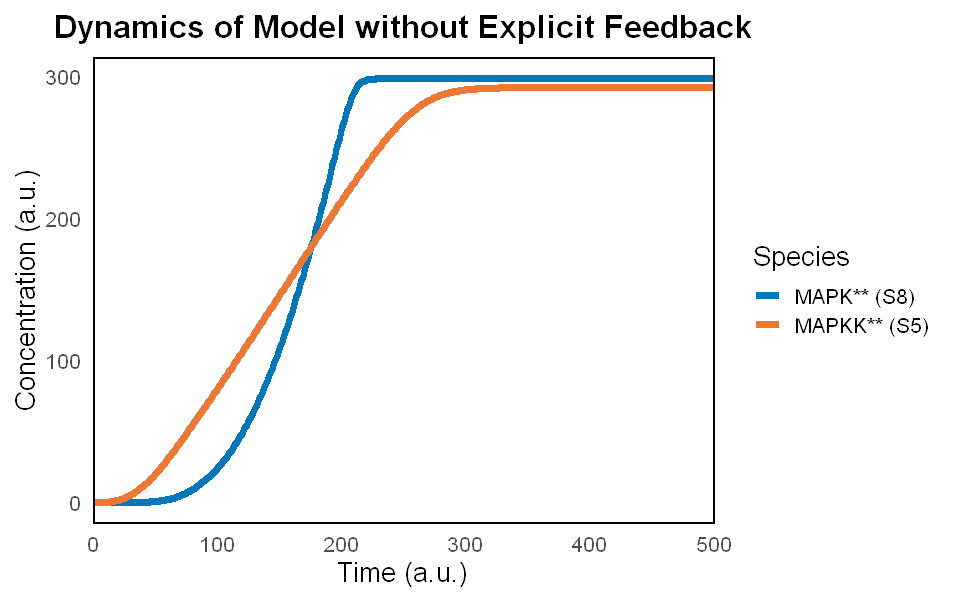

In [134]:
options(repr.plot.width = 8, repr.plot.height = 5)
colors <- c(
  `MAPKK** (S5)` = "#EE7733",
  `MAPK** (S8)` = "#0077BB"
)

plot1 <- ggplot(sol_long, aes(x = time, y = value, colour = species)) +
  geom_line(linewidth = 2) +
  scale_colour_manual(values = colors) + # scale_colour_brewer(palette = "Dark2") +
  scale_x_continuous(
    breaks = seq(0, 500, 100),
    minor_breaks = seq(0, 500, 50),
    limits = c(0, 500),
    expand = c(0, 0)
  ) +
  coord_cartesian(xlim = c(0, 500), clip = "on") +
  labs(
    title = "Dynamics of Model without Explicit Feedback",
    x = "Time (a.u.)",
    y = "Concentration (a.u.)",
    colour = "Species"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    plot.title = element_text(face = "bold", hjust = 0.5),
    # panel.grid.minor = element_blank(),
    panel.grid = element_blank(),

    ## black outer box
    panel.border = element_rect(
      colour = "black",
      fill = NA,
      linewidth = 1.1
    )
  )

plot1
# ggsave("POSm4_plot.png", plot1, width = 10, height = 8, units = "in", dpi = 300)

In [137]:
res_tab <- find_loops_vset(model_mapk_simple_wo_feedback,vset=list(sol[dim(sol)[1],2:9]),t=1,klin=klin,kn=kn,n1=n1)
loop_summary(res_tab$loop_rep[[1]])

,len_1,len_2
,<dbl>,<dbl>
all,8,5
pos,0,5
neg,8,0
